In [1]:
# S&P 500, T=132: derive and validate the raw arm's correlation threshold C=0.65
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from networks import load_logreturns, rolling_correlations, mu_offdiag, sigma_offdiag, ARM_THRESHOLDS
from plot_style import (
    set_publication_style, style_axis, figsize, save_figure, format_date_axis,
    CRISIS_EVENTS, annotate_events, NEUTRAL_COLOURS,
)
set_publication_style()

FIGURES_DIR = "report/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [2]:
# Config: S&P 500, T=132 (matches the pipeline's own EPOCH_CONFIGS), and the threshold under test
INDEX_CODE = "SP500"
EPOCH_LENGTH = 132
EPOCH_SHIFT = 10
CHOSEN_THRESHOLD = ARM_THRESHOLDS["raw"]

In [3]:
# No precomputed outputs/ pickles needed -- recompute correlations directly via the pipeline's own functions, no graphs built
df_logreturns = load_logreturns(f"data/{INDEX_CODE}_AdjClose_Cleaned.csv")
correlation_matrices, epoch_dates, stock_names = rolling_correlations(df_logreturns, EPOCH_LENGTH, EPOCH_SHIFT)
correlation_matrices = [np.clip(C, -1.0, 1.0) for C in correlation_matrices]
print(f"{INDEX_CODE} T={EPOCH_LENGTH}: {len(correlation_matrices)} windows, N={len(stock_names)} stocks")

C:\Users\Abbin\Desktop\UCL\Regime Detection in Financial Markets using ML\networks.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_logreturns[col] = np.log(df[col]) - np.log(df[col].shift(1))
C:\Users\Abbin\Desktop\UCL\Regime Detection in Financial Markets using ML\networks.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_logreturns[col] = np.log(df[col]) - np.log(df[col].shift(1))
C:\Users\Abbin\Desktop\UCL\Regime Detection in Financial Markets using ML\networks.py:140: PerformanceWarning: DataFrame is highly f

C:\Users\Abbin\Desktop\UCL\Regime Detection in Financial Markets using ML\networks.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_logreturns[col] = np.log(df[col]) - np.log(df[col].shift(1))
C:\Users\Abbin\Desktop\UCL\Regime Detection in Financial Markets using ML\networks.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_logreturns[col] = np.log(df[col]) - np.log(df[col].shift(1))
C:\Users\Abbin\Desktop\UCL\Regime Detection in Financial Markets using ML\networks.py:140: PerformanceWarning: DataFrame is highly f

SP500 T=132: 629 windows, N=349 stocks


In [4]:
# Per-window off-diagonal statistics (mean/median/std/quantiles), diagonal excluded
def offdiag_stats(C):
    vals = C[np.triu_indices_from(C, k=1)]
    return {
        "mean": mu_offdiag(C), "median": float(np.median(vals)), "std": sigma_offdiag(C),
        "q10": float(np.quantile(vals, 0.10)), "q25": float(np.quantile(vals, 0.25)),
        "q75": float(np.quantile(vals, 0.75)), "q90": float(np.quantile(vals, 0.90)),
    }

df_stats = pd.DataFrame([{"date": date, **offdiag_stats(C)} for date, C in zip(epoch_dates, correlation_matrices)])
df_stats

,date,mean,median,std,q10,q25,q75,q90
0,2001-07-12,0.159274,0.153586,0.155575,-0.032414,0.056394,0.255191,0.355074
1,2001-07-26,0.168678,0.160210,0.139292,0.001301,0.076005,0.250874,0.344749
2,2001-08-09,0.174159,0.165009,0.141456,0.004618,0.079127,0.257561,0.353740
3,2001-08-23,0.179846,0.170170,0.141807,0.009721,0.084048,0.263838,0.359730
4,2001-09-07,0.188174,0.178494,0.142546,0.016924,0.091101,0.273302,0.371584
...,...,...,...,...,...,...,...,...
624,2026-05-06,0.157947,0.152259,0.177427,-0.061752,0.038981,0.269471,0.382380
625,2026-05-20,0.156669,0.150608,0.183320,-0.070798,0.034268,0.270009,0.389258
626,2026-06-04,0.143693,0.138779,0.182209,-0.082400,0.024327,0.254276,0.369940
627,2026-06-18,0.143689,0.138989,0.188855,-0.093558,0.019238,0.260496,0.379900


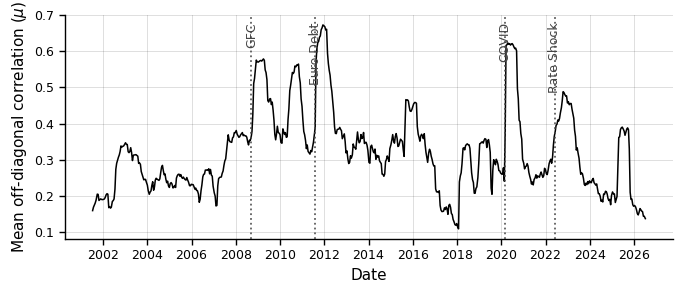

In [5]:
# Mean off-diagonal correlation over time, with historical crisis events annotated
fig, ax = plt.subplots(figsize=figsize(width="double", height=3.0))
ax.plot(df_stats["date"], df_stats["mean"], color=NEUTRAL_COLOURS["primary"], linewidth=1.1)
annotate_events(ax, CRISIS_EVENTS, epoch_dates[0], epoch_dates[-1])
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_xlabel("Date")
ax.set_ylabel(r"Mean off-diagonal correlation ($\mu$)")
fig.tight_layout()
save_figure(fig, os.path.join(FIGURES_DIR, "threshold_meancorr_timeseries.png"))
plt.show()

In [6]:
# Pool every pairwise correlation (all windows, all pairs) -- no networks are ever built, just histogram accumulation
BIN_EDGES = np.linspace(-1.0, 1.0, 201)
bin_centers = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2
hist_counts = np.zeros(len(BIN_EDGES) - 1, dtype=np.int64)
for C in correlation_matrices:
    counts, _ = np.histogram(C[np.triu_indices_from(C, k=1)], bins=BIN_EDGES)
    hist_counts += counts
total_pairs = int(hist_counts.sum())
total_pairs

38196654

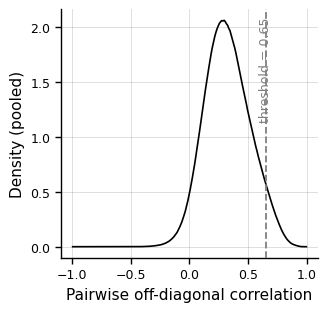

In [7]:
# Pooled distribution of every pairwise correlation across all windows, with the chosen threshold marked
fig, ax = plt.subplots(figsize=figsize(width="single", height=3.2))
density = hist_counts / hist_counts.sum() / (BIN_EDGES[1] - BIN_EDGES[0])
ax.plot(bin_centers, density, color=NEUTRAL_COLOURS["primary"], linewidth=1.2)
ax.axvline(CHOSEN_THRESHOLD, color=NEUTRAL_COLOURS["reference"], linestyle="--", linewidth=1.3, zorder=3)
y_top = ax.get_ylim()[1]
ax.text(CHOSEN_THRESHOLD, y_top * 0.97, f"threshold = {CHOSEN_THRESHOLD:.2f}", rotation=90,
        color=NEUTRAL_COLOURS["reference"], fontsize=9, va="top", ha="center")
style_axis(ax, grid=True)
ax.set_xlabel("Pairwise off-diagonal correlation")
ax.set_ylabel("Density (pooled)")
fig.tight_layout()
save_figure(fig, os.path.join(FIGURES_DIR, "threshold_pooled_distribution.png"))
plt.show()

In [8]:
# Derive the threshold from a fixed rule: the cutoff where 5% of all pooled pairs still exceed it
def frac_exceeding(threshold):
    return hist_counts[bin_centers > threshold].sum() / total_pairs

fine_thresholds = np.linspace(0.0, 0.95, 191)
derived_threshold = next(t for t in fine_thresholds if frac_exceeding(t) <= 0.05)
pd.DataFrame({"derived_5pct_threshold": [derived_threshold], "chosen_threshold": [CHOSEN_THRESHOLD]})

,derived_5pct_threshold,chosen_threshold
0,0.66,0.65


In [9]:
# Robustness: the derived threshold at 1%, 5%, and 10% sparsity targets
targets = [0.10, 0.05, 0.01]
robustness = {f"{int(t*100)}% target": next(s for s in fine_thresholds if frac_exceeding(s) <= t) for t in targets}
pd.DataFrame([robustness])

,10% target,5% target,1% target
0,0.59,0.66,0.775


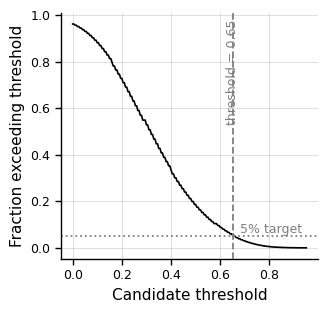

In [10]:
# Fraction of pairs exceeding each candidate threshold, with the chosen threshold and the 5% sparsity target marked
fig, ax = plt.subplots(figsize=figsize(width="single", height=3.2))
fracs = [frac_exceeding(t) for t in fine_thresholds]
ax.plot(fine_thresholds, fracs, color=NEUTRAL_COLOURS["primary"], linewidth=1.2)
ax.axhline(0.05, color=NEUTRAL_COLOURS["reference"], linestyle=":", linewidth=1.3, zorder=2)
ax.axvline(CHOSEN_THRESHOLD, color=NEUTRAL_COLOURS["reference"], linestyle="--", linewidth=1.3, zorder=3)
y_top = ax.get_ylim()[1]
ax.text(CHOSEN_THRESHOLD, y_top * 0.97, f"threshold = {CHOSEN_THRESHOLD:.2f}", rotation=90,
        color=NEUTRAL_COLOURS["reference"], fontsize=9, va="top", ha="center")
ax.text(fine_thresholds[-1], 0.05, "5% target ", color=NEUTRAL_COLOURS["reference"], fontsize=9, va="bottom", ha="right")
style_axis(ax, grid=True)
ax.set_xlabel("Candidate threshold")
ax.set_ylabel("Fraction exceeding threshold")
fig.tight_layout()
save_figure(fig, os.path.join(FIGURES_DIR, "threshold_exceedance_curve.png"))
plt.show()

In [11]:
# Conclusion: the chosen threshold's exceedance fraction, alongside the rule-derived value
pd.DataFrame({
    "chosen_threshold": [CHOSEN_THRESHOLD],
    "derived_5pct_threshold": [derived_threshold],
    "frac_exceeding_at_chosen": [frac_exceeding(CHOSEN_THRESHOLD)],
})

,chosen_threshold,derived_5pct_threshold,frac_exceeding_at_chosen
0,0.65,0.66,0.054505
